In [57]:
# Import the pandas library for data manipulation and analysis
import pandas as pd
# Import the numpy library for numerical operations
import numpy as np
# Import the matplotlib.pyplot library for plotting
import matplotlib.pyplot as plt
# Import the yfinance library to download financial data
import yfinance as yf
# Import the ta library for technical analysis indicators
from ta import add_all_ta_features
# Import the RandomForestClassifier from scikit-learn for building random forest models
from sklearn.ensemble import RandomForestClassifier
# Import the hmm module from hmmlearn for Hidden Markov Models
from hmmlearn import hmm
# Import the adfuller function from statsmodels for the Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
# Import the datetime module to work with dates
import datetime
# Install pyfolio-reloaded to check strategy performance metrics
import pyfolio.timeseries as pf_ts
import warnings
warnings.filterwarnings('ignore')
from ta.volatility import average_true_range
from hmmlearn.hmm import GaussianHMM

from sklearn.ensemble import RandomForestClassifier

from hmmlearn.hmm import GaussianHMM

import numpy as np
import pandas as pd

In [58]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [59]:
import shap

In [60]:
!pip install hmmlearn

In [61]:
pip install pyfolio-reloaded

Note: you may need to restart the kernel to use updated packages.


In [62]:

def get_data(ticker, start_date, end_date):

    # Download stock data
    data = yf.download(
        ticker,
        start=start_date,
        end=end_date,
        auto_adjust=True
    )

    # Flatten columns if multi-index appears

    # Flatten MultiIndex columns properly
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [
        col[0] if col[0] != '' else col[1]
        for col in data.columns
    ]



    # Remove missing rows
    data.dropna(inplace=True)

    # Create returns column
    data['returns'] = data['Close'].pct_change()

    # Remove NaNs created by pct_change
    data.dropna(inplace=True)

    return data





In [63]:
# Define a function to engineer technical features and ensure stationarity
def engineer_features(data_df, num_lead):
    """
    Engineers technical features, ensures stationarity,
    performs feature selection using:
    - Correlation filtering
    - Random Forest importance
    - SHAP values
    """

    # -----------------------------
    # STEP 1: PREPARE OHLCV DATA
    # -----------------------------
    df_input_for_ta = pd.DataFrame(index=data_df.index)

    df_input_for_ta['Open'] = data_df['Open'].astype(float)
    df_input_for_ta['High'] = data_df['High'].astype(float)
    df_input_for_ta['Low'] = data_df['Low'].astype(float)
    df_input_for_ta['Close'] = data_df['Close'].astype(float)
    df_input_for_ta['Volume'] = data_df['Volume'].astype(float)

    # -----------------------------
    # STEP 2: GENERATE TA FEATURES
    # -----------------------------
    features_added_df = add_all_ta_features(
        df_input_for_ta,
        open="Open",
        high="High",
        low="Low",
        close="Close",
        volume="Volume",
        fillna=True
    )

    # Remove original OHLCV columns
    columns_to_drop_from_ta_output = ["Open", "High", "Low", "Close", "Volume"]

    processed_features_df = features_added_df.drop(
        columns=columns_to_drop_from_ta_output,
        errors='ignore'
    )

    # -----------------------------
    # STEP 3: CLEAN FEATURES
    # -----------------------------
    processed_features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    indicators_to_become_stationary = []
    indicators_to_drop = []

    # -----------------------------
    # STEP 4: STATIONARITY CHECK
    # -----------------------------
    for indicator in processed_features_df.columns:

        indicator_series = processed_features_df[indicator].dropna()

        # Insufficient samples
        if len(indicator_series) < 20:
            indicators_to_drop.append(indicator)
            continue

        try:
            # ADF Test
            pvalue = adfuller(
                indicator_series,
                regression='c',
                autolag='AIC'
            )[1]

            # Non-stationary
            if pvalue > 0.05:
                indicators_to_become_stationary.append(indicator)

            # Invalid p-value
            elif np.isnan(pvalue):
                indicators_to_drop.append(indicator)

        except:
            indicators_to_drop.append(indicator)

    # -----------------------------
    # STEP 5: MAKE NON-STATIONARY
    # FEATURES STATIONARY
    # -----------------------------
    if indicators_to_become_stationary:

        processed_features_df.loc[:, indicators_to_become_stationary] = (
            processed_features_df[indicators_to_become_stationary]
            .pct_change()
        )

    # -----------------------------
    # STEP 6: DROP BAD FEATURES
    # -----------------------------
    if indicators_to_drop:

        processed_features_df.drop(
            columns=indicators_to_drop,
            inplace=True,
            errors='ignore'
        )

    # -----------------------------
    # STEP 7: FINAL CLEANING
    # -----------------------------
    processed_features_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Forward fill small gaps
    processed_features_df.ffill(inplace=True)

    # Drop remaining NaNs
    processed_features_df.dropna(inplace=True)

    # -----------------------------
    # STEP 8: CREATE TARGET
    # -----------------------------
    data_with_all_features = pd.concat(
        [data_df, processed_features_df],
        axis=1
    )

    data_with_all_features['y_signal'] = np.where(
        data_with_all_features['returns'].shift(-num_lead) > 0,
        1,
        0
    )

    # Align after target creation
    data_with_all_features.dropna(inplace=True)

    # -----------------------------
    # STEP 9: CORRELATION FILTERING
    # -----------------------------
    feature_cols = processed_features_df.columns.tolist()

    corr_matrix = data_with_all_features[feature_cols].corr().abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    highly_correlated_features = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > 0.90)
    ]

    # Drop highly correlated features
    filtered_feature_df = data_with_all_features[
        feature_cols
    ].drop(columns=highly_correlated_features, errors='ignore')

    # -----------------------------
    # STEP 10: RANDOM FOREST
    # FEATURE IMPORTANCE
    # -----------------------------
    X = filtered_feature_df.copy()
    y = data_with_all_features.loc[X.index, 'y_signal']

    rf_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X, y)

    feature_importance_df = pd.DataFrame({
        'feature': X.columns,
        'importance': rf_model.feature_importances_
    })

    feature_importance_df.sort_values(
        by='importance',
        ascending=False,
        inplace=True
    )

    # Keep top features
    top_rf_features = feature_importance_df[
        feature_importance_df['importance'] > (
            feature_importance_df['importance'].mean()
        )
    ]['feature'].tolist()

    # -----------------------------
    # STEP 11: SHAP FEATURE SELECTION
    # -----------------------------
    X_shap = X[top_rf_features].copy()

    # Train separate RF model for SHAP
    rf_model_shap = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

    rf_model_shap.fit(X_shap, y)

    # SHAP explainer
    explainer = shap.TreeExplainer(rf_model_shap)

    # SHAP values
    shap_values = explainer.shap_values(
        X_shap,
        check_additivity=False)

    # Binary classification
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
        
    # Handle different SHAP output dimensions
    shap_values_array = np.array(shap_values)
    # If 3D: (samples, features, classes)
    if shap_values_array.ndim == 3:
        shap_importance = np.abs(shap_values_array).mean(axis=(0, 2))
        # If 2D: (samples, features)
    else:
        shap_importance = np.abs(shap_values_array).mean(axis=0)



    shap_importance_df = pd.DataFrame({
        'feature': X_shap.columns,
        'shap_importance': shap_importance
    })

    shap_importance_df.sort_values(
        by='shap_importance',
        ascending=False,
        inplace=True
    )

    # Final selected features
    final_feature_columns = shap_importance_df[
        shap_importance_df['shap_importance'] >
        shap_importance_df['shap_importance'].mean()
    ]['feature'].tolist()

    # -----------------------------
    # STEP 12: RETURN FINAL DATA
    # -----------------------------
    return data_with_all_features, final_feature_columns

In [64]:
# Define the main backtesting function
def run_backtest(data_df, feature_list, backtest_signal_start_date_str, num_lead):
    """Runs the event-driven backtest. Signals start from backtest_signal_start_date_str."""
    # Define backtesting parameters
    window_size = 4 * 252  # Rolling window for historical data (4 years)
    train_test_split_days = 90  # Days for the test set
    min_samples_for_rf = 30  # Minimum samples to train a Random Forest model
    
    # Initialize a 'signal' column in the DataFrame
    data_df['signal'] = 0.0

    # Determine the first possible index based on the historical window size
    first_possible_loop_idx_due_to_window = window_size
    target_signal_start_datetime = pd.to_datetime(backtest_signal_start_date_str)
    
    # Find all dates in the index that are on or after the target start date
    dates_after_target = data_df.index[data_df.index >= target_signal_start_datetime]

    # Handle case where start date is after all available data
    if dates_after_target.empty:
        print(f"Target signal start date {backtest_signal_start_date_str} is after the last data point. No backtest performed.")
        return data_df

    # Find the integer location of the first target date
    first_target_date_idx = data_df.index.get_loc(dates_after_target[0])

    # The main loop starts at the later of the two possible start dates
    loop_start_index = max(first_possible_loop_idx_due_to_window, first_target_date_idx)
        # Safety check
    if loop_start_index >= len(data_df):

        print("Not enough data after preprocessing.")

        return data_df

    print(

        f"Backtest signal generation will start from: "

        f"{data_df.index[loop_start_index].strftime('%Y-%m-%d')}"

)

    # Main backtesting loop
    for t in range(loop_start_index, len(data_df)):
        current_prediction_date = data_df.index[t]
        # Extract the historical data sample for this iteration
        data_sample = data_df.iloc[t - window_size : t].copy()

        if len(data_sample) < window_size:
            continue

        # Split the sample into training and test sets
        model_training_data = data_sample.iloc[:-train_test_split_days].copy()

        # Ensure there is enough data to train
        if len(model_training_data) < (min_samples_for_rf * 2):
            data_df.loc[current_prediction_date, 'signal'] = 0.0
            continue

        # --- HMM for Regime Detection ---
        hmm_model = None
        hmm_train_features = model_training_data[['returns']].copy()
        hmm_train_features.dropna(inplace=True)

        if len(hmm_train_features) >= min_samples_for_rf:
            hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=100)
            hmm_model.fit(hmm_train_features)
            regimes_for_rf_training = hmm_model.predict(hmm_train_features)
            model_training_data.loc[hmm_train_features.index, 'regime'] = regimes_for_rf_training

        # --- Regime-Specific Random Forest Models ---
        model0, model1 = None, None
        if 'regime' in model_training_data.columns and feature_list:
            regime_0_data = model_training_data[model_training_data['regime'] == 0].copy()
            regime_1_data = model_training_data[model_training_data['regime'] == 1].copy()

            # Train Model for Regime 0
            if len(regime_0_data) >= min_samples_for_rf and len(regime_0_data['y_signal'].unique()) > 1:
                X0, y0 = regime_0_data[feature_list].iloc[:-num_lead,:], regime_0_data['y_signal'].iloc[:-num_lead]
                model0 = RandomForestClassifier(n_estimators=50, random_state=100)
                model0.fit(X0, y0)

            # Train Model for Regime 1
            if len(regime_1_data) >= min_samples_for_rf and len(regime_1_data['y_signal'].unique()) > 1:
                X1, y1 = regime_1_data[feature_list].iloc[:-num_lead,:], regime_1_data['y_signal'].iloc[:-num_lead]
                model1 = RandomForestClassifier(n_estimators=50, random_state=100)
                model1.fit(X1, y1)

        
        # --- Prediction for the current day ---
        features_for_pred_day = data_sample[feature_list].iloc[-num_lead:].copy() if feature_list else pd.DataFrame()
        hmm_features_for_pred_day = data_sample[['returns']].iloc[-1:].copy()
        next_day_regime_probs = np.array([0.5, 0.5]) # Default probabilities

        # Predict next day's regime probability using HMM transition matrix
        if hmm_model and not hmm_features_for_pred_day.isnull().values.any() and hasattr(hmm_model, 'transmat_'):
            last_day_state_probs = hmm_model.predict_proba(hmm_features_for_pred_day)[0]
            next_day_regime_probs = last_day_state_probs @ hmm_model.transmat_

        # Generate signals from each model
        signal0, signal1 = 0.0, 0.0
        
        # Check if model0 can predict
        if model0 and not features_for_pred_day.empty and \
           not (features_for_pred_day.isnull().values.any() or np.isinf(features_for_pred_day.values).any()):
            signal0 = model0.predict_proba(features_for_pred_day)[0][1]
        
        # Check if model1 can predict
        if model1 and not features_for_pred_day.empty and \
           not (features_for_pred_day.isnull().values.any() or np.isinf(features_for_pred_day.values).any()):
            signal1 = model1.predict_proba(features_for_pred_day)[0][1]

        # Combine signals based on regime probability
        if next_day_regime_probs[0] > next_day_regime_probs[1]:
            final_signal = signal0
        elif next_day_regime_probs[1] > next_day_regime_probs[0]:
            final_signal = signal1
        else: # If probabilities are equal, remain neutral
            final_signal = 0.0
       # Limit threshold for the signal probability as a risk management tool
        limit = 0.03 # 3 is best up to now
        # Store the final signal in the DataFrame
        data_df.loc[current_prediction_date, 'signal'] = 1 if final_signal>(0.5+limit) else -1 if final_signal<(0.5-limit) else 0

        if t % 100 == 0:
            print(f"Processed up to {current_prediction_date.strftime('%Y-%m-%d')}, Signal: {final_signal}")

    return data_df

In [65]:
# Define a function to plot the backtesting results
def plot_results(results_df, ticker):
    """Plots cumulative returns."""
    # Check if the results DataFrame is empty
    if results_df.empty:
        print(f"No results to plot for {ticker}.")
        return

    # Calculate cumulative returns for a Buy-and-Hold strategy
    results_df['bh_cum_rets'] = (1 + results_df['returns']).cumprod()
    # Calculate strategy returns by multiplying daily returns with the trading signal
    results_df['strategy_returns'] = results_df['returns'] * results_df['signal']
    results_df.dropna(subset=['strategy_returns'], inplace=True)

    # Check if there are any valid returns left to plot
    if results_df.empty or results_df['strategy_returns'].isnull().all():
        print(f"No valid strategy returns to plot for {ticker} after processing.")
        return

    # Calculate cumulative returns for the HMM-RF strategy
    results_df['strategy_cum_rets'] = (1 + results_df['strategy_returns']).cumprod()

    # Create the plot
    plt.figure(figsize=(15, 7))
    plt.plot(results_df['bh_cum_rets'], label="Buy-and-Hold")
    plt.plot(results_df['strategy_cum_rets'], label="HMM-RF Strategy")
    plt.title(f'{ticker} Strategy Cumulative Returns', fontsize=16)
    plt.xlabel('Date', fontsize=15)
    plt.ylabel('Cumulative Returns', fontsize=15)
    plt.tick_params(axis='both', labelsize=15)
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

In [66]:
def compute_perf_stats(results_to_plot):
    # --- Calculate Performance Statistics ---
    strategy_stats = pf_ts.perf_stats(results_to_plot['strategy_returns'])
    bh_stats = pf_ts.perf_stats(results_to_plot['bh_cum_rets'].pct_change().fillna(0))
    
    # --- Combine Statistics into a Single Table ---
    # Concatenate the two series into a single DataFrame.
    perf_table = pd.concat([bh_stats, strategy_stats], axis=1)
    perf_table.columns = ['Buy & Hold', 'Strategy'] # Set the column names
    
    # --- Filter for Desired Metrics ---
    # Create a list of the specific metrics you want to see.
    desired_metrics = [
        'Annual return',
        'Cumulative returns',
        'Annual volatility',
        'Sharpe ratio',
        'Calmar ratio',
        'Max drawdown',
        'Sortino ratio',
    ]
    
    # Select only the rows that match your desired metrics.
    final_table = perf_table.loc[desired_metrics]
    
    for index in final_table.index:
        if index in ['Annual return', 'Cumulative returns', 'Annual volatility', 'Max drawdown']:
            for column in final_table.columns:
                final_table.loc[index,column] = f'{round(final_table.loc[index,column]*100,2):.2f}%'
        else:
            for column in final_table.columns:
                final_table.loc[index,column] = f'{round(final_table.loc[index,column],2):.2f}'
    
    # Print the table
    print(final_table)

[*********************100%***********************]  1 of 1 completed


                 Close        High         Low        Open   Volume   returns
Date                                                                         
2020-01-02  631.303772  636.545282  628.038566  634.912706  5658200 -0.002918
2020-01-03  641.013428  642.731962  630.616314  630.616314  7882938  0.015380
2020-01-06  634.869690  647.715748  632.850433  641.099379  6519403 -0.009584
2020-01-07  625.460632  638.091819  623.054642  634.139210  7899363 -0.014820
2020-01-08  617.125793  626.405870  608.619026  622.925848  8639443 -0.013326
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'returns'], dtype='object')
Data prepared. Number of features: 18
Data shape after preprocessing: (1573, 93)
Backtest signal generation will start from: 2024-01-30


Model is not converging.  Current: 2483.5828326405676 is not greater than 2483.586266839766. Delta is -0.0034341991981818865
Model is not converging.  Current: 2486.1101242105424 is not greater than 2486.1139684204886. Delta is -0.0038442099462372425
Model is not converging.  Current: 2484.982652249928 is not greater than 2484.9868476411702. Delta is -0.004195391242319602
Model is not converging.  Current: 2490.5220995692825 is not greater than 2490.528554722787. Delta is -0.006455153504248301
Model is not converging.  Current: 2490.0259768231144 is not greater than 2490.027512867413. Delta is -0.0015360442985183909
Model is not converging.  Current: 2491.2836663868834 is not greater than 2491.2869305035924. Delta is -0.00326411670903326
Model is not converging.  Current: 2492.7700288274664 is not greater than 2492.775865009103. Delta is -0.005836181636823312
Model is not converging.  Current: 2494.691222416322 is not greater than 2494.6926911763708. Delta is -0.0014687600487377495
Mod

Processed up to 2024-06-18, Signal: 0.48
Processed up to 2024-11-08, Signal: 0.34
Processed up to 2025-04-04, Signal: 0.5
Processed up to 2025-09-01, Signal: 0.52
Processed up to 2026-01-23, Signal: 0.34


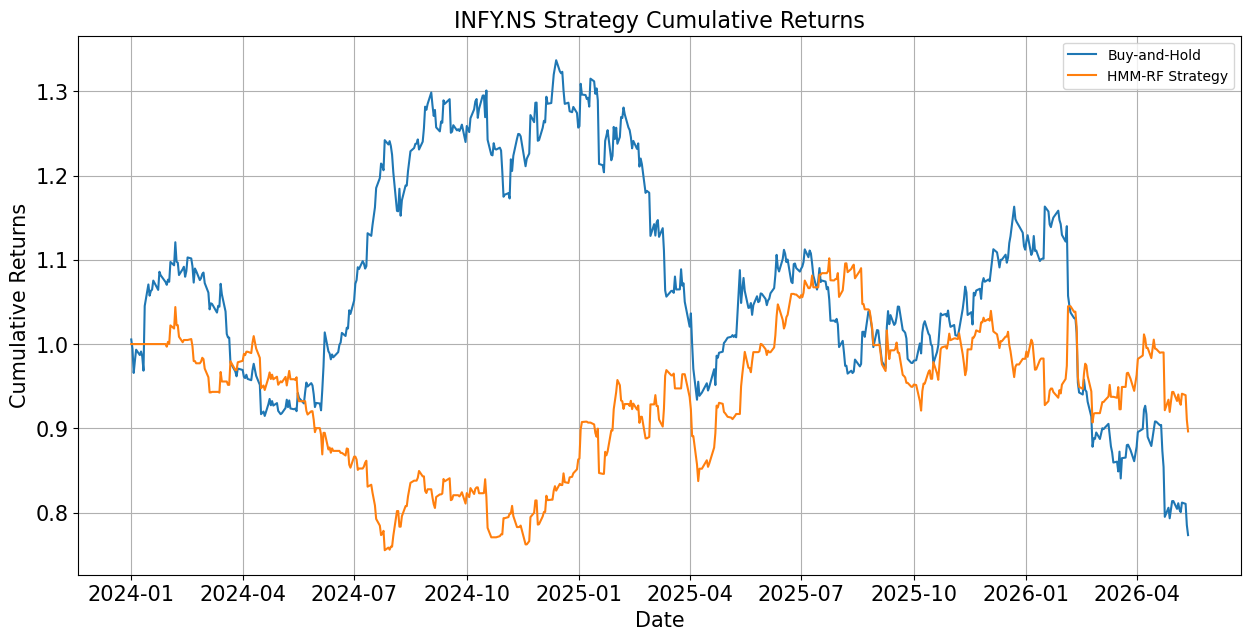

                   Buy & Hold Strategy
Annual return         -10.72%   -4.61%
Cumulative returns    -23.11%  -10.37%
Annual volatility      25.20%   21.71%
Sharpe ratio            -0.32    -0.11
Calmar ratio            -0.25    -0.17
Max drawdown          -42.17%  -27.66%
Sortino ratio           -0.45    -0.15


In [67]:
#CHANGE
# Main execution block: This code runs when the script is executed directly
from datetime import datetime
if __name__ == '__main__':
    # Define script parameters
    TICKER = 'INFY.NS'
    START_DATE = '2020-01-01'
    END_DATE = '2026-05-14'
    BACKTEST_SIGNAL_START_DATE = '2024-01-01'
    NUM_LEAD = 1

    # 1. Download and prepare the raw historical data
    raw_data = get_data(TICKER, START_DATE, END_DATE)
    print(raw_data.head())
    print(raw_data.columns)
    
    # 2. Engineer features from the raw data
    data_with_features, feature_cols = engineer_features(raw_data.copy(), NUM_LEAD)

    print(f"Data prepared. Number of features: {len(feature_cols)}")
    print(f"Data shape after preprocessing: {data_with_features.shape}")

    # 3. Run the backtest
    results_df = run_backtest(data_with_features.copy(), feature_cols, BACKTEST_SIGNAL_START_DATE, NUM_LEAD)
    
    # 4. Filter results for the plotting period
    results_to_plot = results_df[results_df.index >= pd.to_datetime(BACKTEST_SIGNAL_START_DATE)].copy()

    # 5. Plot the results
    plot_results(results_to_plot, TICKER)

    # 6. Compute performance statistics 
    compute_perf_stats(results_to_plot)

In [68]:
print(feature_cols)

['volume_adi', 'trend_dpo', 'volume_obv', 'volatility_kcw', 'volume_em', 'volume_cmf', 'trend_mass_index', 'momentum_uo', 'volume_vpt', 'momentum_pvo', 'trend_ichimoku_conv', 'volatility_bbm', 'volatility_bbw', 'trend_visual_ichimoku_a', 'trend_kst_diff', 'others_dr', 'volatility_kcc', 'volume_sma_em']


In [69]:
fixed_features = ['volume_nvi', 'volume_adi', 'others_dr', 'volume_obv', 'volatility_bbw', 'volume_fi', 'trend_dpo', 'momentum_pvo_hist', 'trend_adx', 'volume_cmf', 'volatility_ui', 'others_cr', 'volume_vwap', 'momentum_kama', 'volatility_kcw'
    
]

NOW ADDING HURST FILTER TO CHECK THE PERSISTENCE EFFECT AND MEMORYNESS OF THE TREND IN THE MARKET AFTER USING THE REGIME FILTERING AND THEN AGAIN CHECKING THE RATIOS TO KNOW HOW MUCH IMPROVEMENT CAN BE DONE IN THIS STRATEGY 

In [70]:

# ---------------------------------------------------
# HURST EXPONENT CALCULATION USING R/S METHOD
# ---------------------------------------------------

def calculate_hurst(ts):

    """
    Calculates Hurst Exponent using
    Rescaled Range (R/S) analysis.
    """

    ts = np.array(ts)

    # Minimum required observations
    if len(ts) < 100:
        return np.nan

    # Different chunk sizes
    chunk_sizes = [5, 10, 20, 40]

    rs_values = []
    log_sizes = []

    for chunk_size in chunk_sizes:

        # Skip invalid chunk sizes
        if chunk_size >= len(ts):
            continue

        # Number of chunks
        num_chunks = len(ts) // chunk_size

        rs_chunk_values = []

        for i in range(num_chunks):

            # Extract chunk
            chunk = ts[i * chunk_size:(i + 1) * chunk_size]

            # Step 1: Mean
            mean_chunk = np.mean(chunk)

            # Step 2: Standard deviation
            std_chunk = np.std(chunk)

            # Avoid division by zero
            if std_chunk == 0:
                continue

            # Step 3: Mean-centered series
            mean_centered = chunk - mean_chunk

            # Step 4: Cumulative sum
            cumulative_series = np.cumsum(mean_centered)

            # Step 5: Range
            R = np.max(cumulative_series) - np.min(cumulative_series)

            # Step 6: Rescaled range
            RS = R / std_chunk

            rs_chunk_values.append(RS)

        # Average R/S for this chunk size
        if len(rs_chunk_values) > 0:

            avg_rs = np.mean(rs_chunk_values)

            rs_values.append(np.log(avg_rs))
            log_sizes.append(np.log(chunk_size))

    # Need enough points for regression
    if len(rs_values) < 2:
        return np.nan

    # Step 7: Hurst = slope of log-log regression
    hurst = np.polyfit(log_sizes, rs_values, 1)[0]

    return hurst



In [71]:

# ---------------------------------------------------
# ADD ROLLING HURST EXPONENT
# ---------------------------------------------------

# Rolling window for Hurst calculation
hurst_window = 100

# Calculate rolling Hurst exponent
data_with_features['hurst'] = (
    data_with_features['returns']
    .rolling(hurst_window)
    .apply(calculate_hurst, raw=False)
)

# Drop NaNs created by rolling calculation
data_with_features.dropna(inplace=True)



In [72]:
# ADDING THE NEW HURST ENHANCED STRATEGY
def run_backtest_hurst(data_df, feature_list, backtest_signal_start_date_str, num_lead):
    """Runs the event-driven backtest. Signals start from backtest_signal_start_date_str."""
    # Define backtesting parameters
    window_size = 4 * 252  # Rolling window for historical data (4 years)
    train_test_split_days = 90  # Days for the test set
    min_samples_for_rf = 30  # Minimum samples to train a Random Forest model
    
    # Initialize a 'signal' column in the DataFrame
    data_df['signal'] = 0.0

    # Determine the first possible index based on the historical window size
    first_possible_loop_idx_due_to_window = window_size
    target_signal_start_datetime = pd.to_datetime(backtest_signal_start_date_str)
    
    # Find all dates in the index that are on or after the target start date
    dates_after_target = data_df.index[data_df.index >= target_signal_start_datetime]

    # Handle case where start date is after all available data
    if dates_after_target.empty:
        print(f"Target signal start date {backtest_signal_start_date_str} is after the last data point. No backtest performed.")
        return data_df

    # Find the integer location of the first target date
    first_target_date_idx = data_df.index.get_loc(dates_after_target[0])

    # The main loop starts at the later of the two possible start dates
    loop_start_index = max(first_possible_loop_idx_due_to_window, first_target_date_idx)
    print(f"Backtest signal generation will start from: {data_df.index[loop_start_index].strftime('%Y-%m-%d')}")

    # Main backtesting loop
    for t in range(loop_start_index, len(data_df)):
        current_prediction_date = data_df.index[t]
        # Extract the historical data sample for this iteration
        data_sample = data_df.iloc[t - window_size : t].copy()

        if len(data_sample) < window_size:
            continue

        # Split the sample into training and test sets
        model_training_data = data_sample.iloc[:-train_test_split_days].copy()

        # Ensure there is enough data to train
        if len(model_training_data) < (min_samples_for_rf * 2):
            data_df.loc[current_prediction_date, 'signal'] = 0.0
            continue

        # --- HMM for Regime Detection ---
        hmm_model = None
        hmm_train_features = model_training_data[['returns']].copy()
        hmm_train_features.dropna(inplace=True)

        if len(hmm_train_features) >= min_samples_for_rf:
            hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=100)
            hmm_model.fit(hmm_train_features)
            regimes_for_rf_training = hmm_model.predict(hmm_train_features)
            model_training_data.loc[hmm_train_features.index, 'regime'] = regimes_for_rf_training

        # --- Regime-Specific Random Forest Models ---
        model0, model1 = None, None
        if 'regime' in model_training_data.columns and feature_list:
            regime_0_data = model_training_data[model_training_data['regime'] == 0].copy()
            regime_1_data = model_training_data[model_training_data['regime'] == 1].copy()

            # Train Model for Regime 0
            if len(regime_0_data) >= min_samples_for_rf and len(regime_0_data['y_signal'].unique()) > 1:
                X0, y0 = regime_0_data[feature_list].iloc[:-num_lead,:], regime_0_data['y_signal'].iloc[:-num_lead]
                model0 = RandomForestClassifier(n_estimators=50, random_state=100)
                model0.fit(X0, y0)

            # Train Model for Regime 1
            if len(regime_1_data) >= min_samples_for_rf and len(regime_1_data['y_signal'].unique()) > 1:
                X1, y1 = regime_1_data[feature_list].iloc[:-num_lead,:], regime_1_data['y_signal'].iloc[:-num_lead]
                model1 = RandomForestClassifier(n_estimators=50, random_state=100)
                model1.fit(X1, y1)

        
        # --- Prediction for the current day ---
        features_for_pred_day = data_sample[feature_list].iloc[-num_lead:].copy() if feature_list else pd.DataFrame()
        hmm_features_for_pred_day = data_sample[['returns']].iloc[-1:].copy()
        next_day_regime_probs = np.array([0.5, 0.5]) # Default probabilities

        # Predict next day's regime probability using HMM transition matrix
        if hmm_model and not hmm_features_for_pred_day.isnull().values.any() and hasattr(hmm_model, 'transmat_'):
            last_day_state_probs = hmm_model.predict_proba(hmm_features_for_pred_day)[0]
            next_day_regime_probs = last_day_state_probs @ hmm_model.transmat_

        # Generate signals from each model
        signal0, signal1 = 0.0, 0.0
        
        # Check if model0 can predict
        if model0 and not features_for_pred_day.empty and \
           not (features_for_pred_day.isnull().values.any() or np.isinf(features_for_pred_day.values).any()):
            signal0 = model0.predict_proba(features_for_pred_day)[0][1]
        
        # Check if model1 can predict
        if model1 and not features_for_pred_day.empty and \
           not (features_for_pred_day.isnull().values.any() or np.isinf(features_for_pred_day.values).any()):
            signal1 = model1.predict_proba(features_for_pred_day)[0][1]

        # Combine signals based on regime probability
        if next_day_regime_probs[0] > next_day_regime_probs[1]:
            final_signal = signal0
        elif next_day_regime_probs[1] > next_day_regime_probs[0]:
            final_signal = signal1
        else: # If probabilities are equal, remain neutral
            final_signal = 0.0
       # Limit threshold for the signal probability as a risk management tool
       # HURST FILTER
       # Current Hurst value
        hurst_value = data_df.loc[current_prediction_date, 'hurst']
        # Signal threshold
        limit = 0.01
        # Apply Hurst persistence filter
        # Trade only in persistent markets 
        if hurst_value > 0.55: 
            # Direction only 
            if final_signal > 0.5:
                 data_df.loc[current_prediction_date, 'signal'] = 1 
            else: data_df.loc[current_prediction_date, 'signal'] = -1 
            # No trade in noisy markets 
        else: data_df.loc[current_prediction_date, 'signal'] = 0
# No trade in random / mean-reverting market
    else:
        data_df.loc[current_prediction_date, 'signal'] = 0



        if t % 100 == 0: 
                        print(f"Processed up to {current_prediction_date.strftime('%Y-%m-%d')}, Signal: {final_signal}")

        return data_df

In [73]:

# ---------------------------------------------------
# PLOT RESULTS - HURST STRATEGY
# ---------------------------------------------------

def plot_results_hurst(results_df, ticker):

    """
    Plot cumulative returns for
    HMM + RF + Hurst strategy.
    """

    if results_df.empty:
        print(f"No results to plot for {ticker}.")
        return

    # Buy & Hold cumulative returns
    results_df['bh_cum_rets'] = (
        1 + results_df['returns']
    ).cumprod()

    # Strategy returns
    results_df['strategy_returns'] = (
        results_df['returns']
        * results_df['signal']
    )

    results_df.dropna(
        subset=['strategy_returns'],
        inplace=True
    )

    if (
        results_df.empty
        or results_df['strategy_returns'].isnull().all()
    ):
        print(
            f"No valid strategy returns "
            f"to plot for {ticker}."
        )
        return

    # Strategy cumulative returns
    results_df['strategy_cum_rets'] = (
        1 + results_df['strategy_returns']
    ).cumprod()

    # Plot
    plt.figure(figsize=(15, 7))

    plt.plot(
        results_df['bh_cum_rets'],
        label="Buy-and-Hold"
    )

    plt.plot(
        results_df['strategy_cum_rets'],
        label="HMM-RF-Hurst Strategy"
    )

    plt.title(
        f'{ticker} Hurst Enhanced Strategy Returns',
        fontsize=16
    )

    plt.xlabel('Date', fontsize=15)
    plt.ylabel('Cumulative Returns', fontsize=15)

    plt.legend(loc='best')

    plt.grid(True)

    plt.show()


     

In [74]:

# ---------------------------------------------------
# PERFORMANCE METRICS - HURST STRATEGY
# ---------------------------------------------------

def compute_perf_stats_hurst(results_to_plot):

    # Performance statistics
    strategy_stats = pf_ts.perf_stats(
        results_to_plot['strategy_returns']
    )

    bh_stats = pf_ts.perf_stats(
        results_to_plot['bh_cum_rets']
        .pct_change()
        .fillna(0)
    )

    # Combine into table
    perf_table = pd.concat(
        [bh_stats, strategy_stats],
        axis=1
    )

    perf_table.columns = [
        'Buy & Hold',
        'HMM-RF-Hurst'
    ]

    # Metrics to display
    desired_metrics = [

        'Annual return',
        'Cumulative returns',
        'Annual volatility',
        'Sharpe ratio',
        'Calmar ratio',
        'Max drawdown',
        'Sortino ratio'

    ]

    final_table = perf_table.loc[desired_metrics]

    # Formatting
    for index in final_table.index:

        if index in [

            'Annual return',
            'Cumulative returns',
            'Annual volatility',
            'Max drawdown'

        ]:

            for column in final_table.columns:

                final_table.loc[index, column] = (
                    f'{round(final_table.loc[index, column] * 100, 2):.2f}%'
                )

        else:

            for column in final_table.columns:

                final_table.loc[index, column] = (
                    f'{round(final_table.loc[index, column], 2):.2f}'
                )

    print(final_table)



[*********************100%***********************]  1 of 1 completed


count    1474.000000
mean        0.598503
std         0.061242
min         0.390352
25%         0.562456
50%         0.601345
75%         0.641826
max         0.768223
Name: hurst, dtype: float64
Data prepared. Features: 18
Final shape: (1474, 94)
Backtest signal generation will start from: 2024-06-27


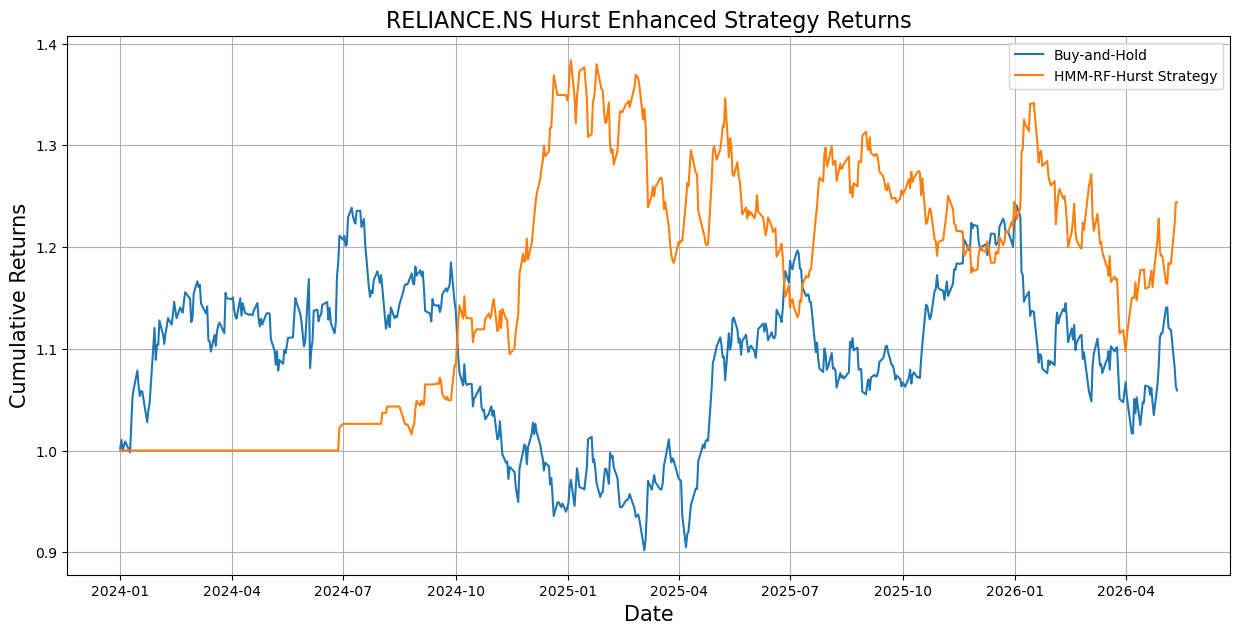

                   Buy & Hold HMM-RF-Hurst
Annual return           2.42%        9.88%
Cumulative returns      5.69%       24.39%
Annual volatility      21.98%       17.50%
Sharpe ratio             0.22         0.63
Calmar ratio             0.09         0.48
Max drawdown          -27.18%      -20.68%
Sortino ratio            0.32         0.91


In [75]:

# ---------------------------------------------------
# MAIN EXECUTION BLOCK - HURST STRATEGY
# ---------------------------------------------------

from datetime import datetime

if __name__ == '__main__':

    # Parameters
    TICKER = 'RELIANCE.NS'

    START_DATE = '2020-01-01'

    END_DATE = '2026-05-14'

    BACKTEST_SIGNAL_START_DATE = '2024-01-01'

    NUM_LEAD = 1

    # -----------------------------------
    # DOWNLOAD DATA
    # -----------------------------------

    raw_data = get_data(
        TICKER,
        START_DATE,
        END_DATE
    )

    # -----------------------------------
    # FEATURE ENGINEERING
    # -----------------------------------

    data_with_features, fixed_features = (
        engineer_features(
            raw_data.copy(),
            NUM_LEAD
        )
    )

    # -----------------------------------
    # HURST CALCULATION
    # -----------------------------------

    hurst_window = 100

    data_with_features['hurst'] = (

        data_with_features['returns']

        .rolling(hurst_window)

        .apply(calculate_hurst, raw=False)

    )
    
    print(data_with_features['hurst'].describe())



    # Remove NaNs
    data_with_features.dropna(inplace=True)

    print(
        f"Data prepared. "
        f"Features: {len(feature_cols)}"
    )

    print(
        f"Final shape: "
        f"{data_with_features.shape}"
    )

    # -----------------------------------
    # RUN HURST BACKTEST
    # -----------------------------------

    results_df_hurst = run_backtest_hurst(

        data_with_features.copy(),

        fixed_features,

        BACKTEST_SIGNAL_START_DATE,

        NUM_LEAD

    )

    # -----------------------------------
    # FILTER PLOTTING PERIOD
    # -----------------------------------

    results_to_plot_hurst = (

        results_df_hurst[
            results_df_hurst.index >=
            pd.to_datetime(BACKTEST_SIGNAL_START_DATE)
        ].copy()

    )

    # -----------------------------------
    # PLOT RESULTS
    # -----------------------------------

    plot_results_hurst(
        results_to_plot_hurst,
        TICKER
    )

    # -----------------------------------
    # PERFORMANCE METRICS
    # -----------------------------------

    compute_perf_stats_hurst(
        results_to_plot_hurst
    )



In [76]:
print(results_df_hurst['signal'].value_counts())

signal
 0.0    1067
-1.0     293
 1.0     114
Name: count, dtype: int64


In [77]:

# ---------------------------------------------------
# SHANNON ENTROPY CALCULATION
# ---------------------------------------------------

def calculate_shannon_entropy(series, bins=10):

    """
    Calculates normalized Shannon entropy.
    """

    series = np.array(series)

    if len(series) == 0:
        return np.nan

    hist, _ = np.histogram(series, bins=bins)

    probabilities = hist / np.sum(hist)

    probabilities = probabilities[probabilities > 0]

    entropy = -np.sum(
        probabilities * np.log(probabilities)
    )

    # Normalize entropy to 0-1
    normalized_entropy = entropy / np.log(bins)

    return normalized_entropy



In [78]:

# ---------------------------------------------------
# ENTROPY CALCULATIONS
# ---------------------------------------------------

entropy_window = 20
entropy_smoothing = 10
entropy_bins = 10

# Rolling Shannon entropy
data_with_features['entropy'] = (

    data_with_features['returns']

    .rolling(entropy_window)

    .apply(
        lambda x: calculate_shannon_entropy(
            x,
            bins=entropy_bins
        ),
        raw=False
    )

)

# Smoothed entropy
data_with_features['entropy_smooth'] = (

    data_with_features['entropy']

    .ewm(span=entropy_smoothing)

    .mean()

)



In [79]:

# ---------------------------------------------------
# ADAPTIVE ENTROPY THRESHOLD
# ---------------------------------------------------

adaptation_window = 100
entropy_percentile = 80

# Rolling adaptive threshold
data_with_features['entropy_threshold'] = (

    data_with_features['entropy_smooth']

    .rolling(adaptation_window)

    .quantile(entropy_percentile / 100)

)

# Final entropy score
data_with_features['entropy_score'] = np.maximum(

    0,

    1 - (
        data_with_features['entropy_smooth']
        /
        data_with_features['entropy_threshold']
    )

)

# Remove NaNs
data_with_features.dropna(inplace=True)



In [80]:
import ta
# ---------------------------------------------------
# ADAPTIVE SUPERTREND
# ---------------------------------------------------

atr_period = 10

base_multiplier = 2.0
max_multiplier = 5.0

data_with_features['atr'] = ta.volatility.average_true_range(

    high=data_with_features['High'],

    low=data_with_features['Low'],

    close=data_with_features['Close'],

    window=atr_period

)

# Dynamic multiplier
data_with_features['dynamic_multiplier'] = (

    base_multiplier +

    (
        max_multiplier - base_multiplier
    )

    * (1 - data_with_features['entropy_score'])

)

# Mid-price
hl2 = (
    data_with_features['High']
    +
    data_with_features['Low']
) / 2

# Bands
data_with_features['supertrend_upper'] = (

    hl2 -

    (
        data_with_features['dynamic_multiplier']
        *
        data_with_features['atr']
    )

)

data_with_features['supertrend_lower'] = (

    hl2 +

    (
        data_with_features['dynamic_multiplier']
        *
        data_with_features['atr']
    )

)


In [81]:

# ---------------------------------------------------
# SUPERTREND DIRECTION
# ---------------------------------------------------

data_with_features['supertrend_direction'] = np.where(

    data_with_features['Close']
    >
    data_with_features['supertrend_lower'].shift(1),

    1,

    np.where(

        data_with_features['Close']
        <
        data_with_features['supertrend_upper'].shift(1),

        -1,

        0
    )
)



In [82]:
# Define the main backtesting function
def run_backtest_entropy_supertrend(data_df, feature_list, backtest_signal_start_date_str, num_lead):
    """Runs the event-driven backtest. Signals start from backtest_signal_start_date_str."""
    # Define backtesting parameters
    window_size = 4 * 252  # Rolling window for historical data (4 years)
    train_test_split_days = 90  # Days for the test set
    min_samples_for_rf = 30  # Minimum samples to train a Random Forest model
    
    # Initialize a 'signal' column in the DataFrame
    data_df['signal'] = 0.0

    # Determine the first possible index based on the historical window size
    first_possible_loop_idx_due_to_window = window_size
    target_signal_start_datetime = pd.to_datetime(backtest_signal_start_date_str)
    
    # Find all dates in the index that are on or after the target start date
    dates_after_target = data_df.index[data_df.index >= target_signal_start_datetime]

    # Handle case where start date is after all available data
    if dates_after_target.empty:
        print(f"Target signal start date {backtest_signal_start_date_str} is after the last data point. No backtest performed.")
        return data_df

    # Find the integer location of the first target date
    first_target_date_idx = data_df.index.get_loc(dates_after_target[0])

    # The main loop starts at the later of the two possible start dates
    loop_start_index = max(first_possible_loop_idx_due_to_window, first_target_date_idx)
    print(f"Backtest signal generation will start from: {data_df.index[loop_start_index].strftime('%Y-%m-%d')}")

    # Main backtesting loop
    for t in range(loop_start_index, len(data_df)):
        current_prediction_date = data_df.index[t]
        # Extract the historical data sample for this iteration
        data_sample = data_df.iloc[t - window_size : t].copy()

        if len(data_sample) < window_size:
            continue

        # Split the sample into training and test sets
        model_training_data = data_sample.iloc[:-train_test_split_days].copy()

        # Ensure there is enough data to train
        if len(model_training_data) < (min_samples_for_rf * 2):
            data_df.loc[current_prediction_date, 'signal'] = 0.0
            continue

        # --- HMM for Regime Detection ---
        hmm_model = None
        hmm_train_features = model_training_data[['returns']].copy()
        hmm_train_features.dropna(inplace=True)

        if len(hmm_train_features) >= min_samples_for_rf:
            hmm_model = hmm.GaussianHMM(n_components=2, covariance_type="diag", n_iter=100, random_state=100)
            hmm_model.fit(hmm_train_features)
            regimes_for_rf_training = hmm_model.predict(hmm_train_features)
            model_training_data.loc[hmm_train_features.index, 'regime'] = regimes_for_rf_training

        # --- Regime-Specific Random Forest Models ---
        model0, model1 = None, None
        if 'regime' in model_training_data.columns and feature_list:
            regime_0_data = model_training_data[model_training_data['regime'] == 0].copy()
            regime_1_data = model_training_data[model_training_data['regime'] == 1].copy()

            # Train Model for Regime 0
            if len(regime_0_data) >= min_samples_for_rf and len(regime_0_data['y_signal'].unique()) > 1:
                X0, y0 = regime_0_data[feature_list].iloc[:-num_lead,:], regime_0_data['y_signal'].iloc[:-num_lead]
                model0 = RandomForestClassifier(n_estimators=50, random_state=100)
                model0.fit(X0, y0)

            # Train Model for Regime 1
            if len(regime_1_data) >= min_samples_for_rf and len(regime_1_data['y_signal'].unique()) > 1:
                X1, y1 = regime_1_data[feature_list].iloc[:-num_lead,:], regime_1_data['y_signal'].iloc[:-num_lead]
                model1 = RandomForestClassifier(n_estimators=50, random_state=100)
                model1.fit(X1, y1)

        
        # --- Prediction for the current day ---
        features_for_pred_day = data_sample[feature_list].iloc[-num_lead:].copy() if feature_list else pd.DataFrame()
        hmm_features_for_pred_day = data_sample[['returns']].iloc[-1:].copy()
        next_day_regime_probs = np.array([0.5, 0.5]) # Default probabilities

        # Predict next day's regime probability using HMM transition matrix
        if hmm_model and not hmm_features_for_pred_day.isnull().values.any() and hasattr(hmm_model, 'transmat_'):
            last_day_state_probs = hmm_model.predict_proba(hmm_features_for_pred_day)[0]
            next_day_regime_probs = last_day_state_probs @ hmm_model.transmat_

        # Generate signals from each model
        signal0, signal1 = 0.0, 0.0
        
        # Check if model0 can predict
        if model0 and not features_for_pred_day.empty and \
           not (features_for_pred_day.isnull().values.any() or np.isinf(features_for_pred_day.values).any()):
            signal0 = model0.predict_proba(features_for_pred_day)[0][1]
        
        # Check if model1 can predict
        if model1 and not features_for_pred_day.empty and \
           not (features_for_pred_day.isnull().values.any() or np.isinf(features_for_pred_day.values).any()):
            signal1 = model1.predict_proba(features_for_pred_day)[0][1]

        # Combine signals based on regime probability
        if next_day_regime_probs[0] > next_day_regime_probs[1]:
            final_signal = signal0
        elif next_day_regime_probs[1] > next_day_regime_probs[0]:
            final_signal = signal1
        else: # If probabilities are equal, remain neutral
            final_signal = 0.0
       # Limit threshold for the signal probability as a risk management tool
        # ---------------------------------------------------
    # ---------------------------------------------------
        # ENTROPY FILTER ONLY
        # ---------------------------------------------------

        entropy_score = data_df.loc[
            current_prediction_date,
            'entropy_score'
        ]

        # Trade only in structured markets
        if entropy_score > 0.20:

            if final_signal > 0.5:

                data_df.loc[
                    current_prediction_date,
                    'signal'
                ] = 1

            else:

                data_df.loc[
                    current_prediction_date,
                    'signal'
                ] = -1

        # No trade in chaotic markets
        else:

            data_df.loc[
                current_prediction_date,
                'signal'
            ] = 0
    # No trade in chaotic markets
    else:

        data_df.loc[
            current_prediction_date,
            'signal'
        ] = 0

        if t % 100 == 0:
            print(f"Processed up to {current_prediction_date.strftime('%Y-%m-%d')}, Signal: {final_signal}")

    return data_df

In [83]:
# ---------------------------------------------------
# PLOT RESULTS - SHANNON ENTROPY SUPERTREND 
# ---------------------------------------------------

def plot_results_entropy_supertrend(results_df, ticker):

    """
    Plot cumulative returns for
    HMM + RF + SHANNON ENTROPY SUPERTREND
    """

    if results_df.empty:
        print(f"No results to plot for {ticker}.")
        return

    # Buy & Hold cumulative returns
    results_df['bh_cum_rets'] = (
        1 + results_df['returns']
    ).cumprod()

    # Strategy returns
    results_df['strategy_returns'] = (
        results_df['returns']
        * results_df['signal']
    )

    results_df.dropna(
        subset=['strategy_returns'],
        inplace=True
    )

    if (
        results_df.empty
        or results_df['strategy_returns'].isnull().all()
    ):
        print(
            f"No valid strategy returns "
            f"to plot for {ticker}."
        )
        return

    # Strategy cumulative returns
    results_df['strategy_cum_rets'] = (
        1 + results_df['strategy_returns']
    ).cumprod()

    # Plot
    plt.figure(figsize=(15, 7))

    plt.plot(
        results_df['bh_cum_rets'],
        label="Buy-and-Hold"
    )

    plt.plot(
        results_df['strategy_cum_rets'],
        label="HMM-RF-ENTROPY SUPERTREND Strategy"
    )

    plt.title(
        f'{ticker} ENTROPY SUPERTREND Enhanced Strategy Returns',
        fontsize=16
    )

    plt.xlabel('Date', fontsize=15)
    plt.ylabel('Cumulative Returns', fontsize=15)

    plt.legend(loc='best')

    plt.grid(True)

    plt.show()


     

In [84]:
def compute_perf_stats_entropy_supertrend(results_to_plot):
    # --- Calculate Performance Statistics ---
    strategy_stats = pf_ts.perf_stats(results_to_plot['strategy_returns'])
    bh_stats = pf_ts.perf_stats(results_to_plot['bh_cum_rets'].pct_change().fillna(0))
    
    # --- Combine Statistics into a Single Table ---
    # Concatenate the two series into a single DataFrame.
    perf_table = pd.concat([bh_stats, strategy_stats], axis=1)
    perf_table.columns = ['Buy & Hold', 'Strategy'] # Set the column names
    
    # --- Filter for Desired Metrics ---
    # Create a list of the specific metrics you want to see.
    desired_metrics = [
        'Annual return',
        'Cumulative returns',
        'Annual volatility',
        'Sharpe ratio',
        'Calmar ratio',
        'Max drawdown',
        'Sortino ratio',
    ]
    
    # Select only the rows that match your desired metrics.
    final_table = perf_table.loc[desired_metrics]
    
    for index in final_table.index:
        if index in ['Annual return', 'Cumulative returns', 'Annual volatility', 'Max drawdown']:
            for column in final_table.columns:
                final_table.loc[index,column] = f'{round(final_table.loc[index,column]*100,2):.2f}%'
        else:
            for column in final_table.columns:
                final_table.loc[index,column] = f'{round(final_table.loc[index,column],2):.2f}'
    
    # Print the table
    print(final_table)

[*********************100%***********************]  1 of 1 completed


       entropy_score  supertrend_direction
count    1455.000000           1573.000000
mean        0.055285             -0.000636
std         0.063280              0.025214
min         0.000000             -1.000000
25%         0.004570              0.000000
50%         0.039315              0.000000
75%         0.074272              0.000000
max         0.316077              0.000000
Data prepared. Features: 18
Final shape: (1455, 102)
Backtest signal generation will start from: 2024-07-25


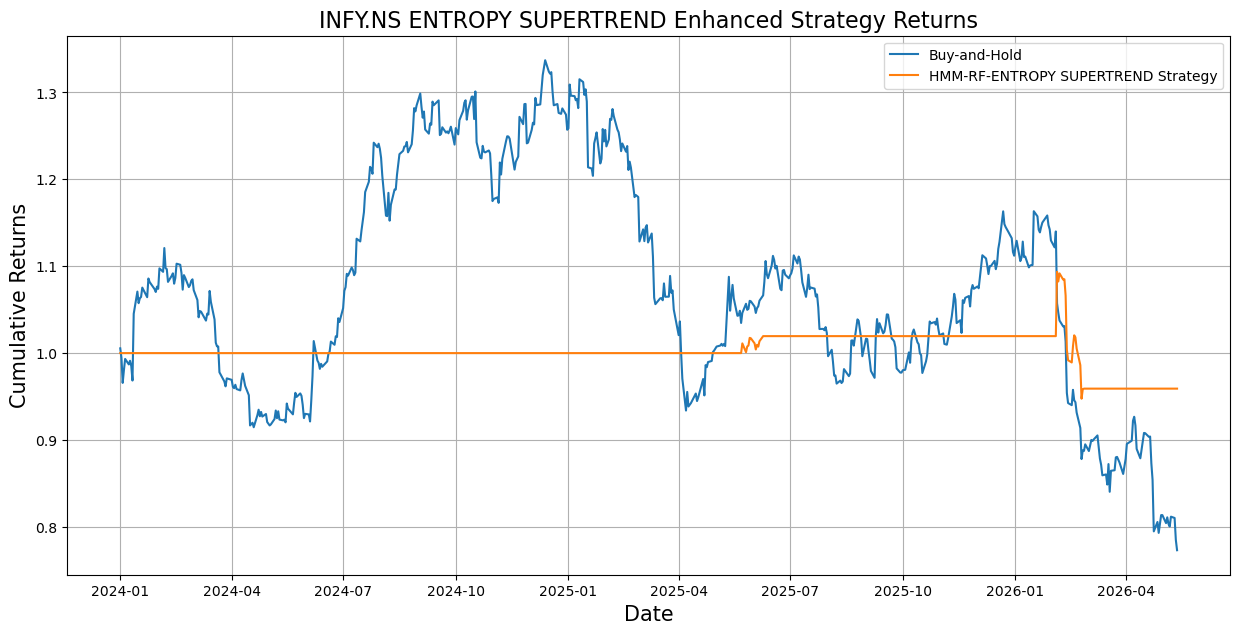

                   Buy & Hold Strategy
Annual return         -10.72%   -1.79%
Cumulative returns    -23.11%   -4.09%
Annual volatility      25.20%    7.37%
Sharpe ratio            -0.32    -0.21
Calmar ratio            -0.25    -0.13
Max drawdown          -42.17%  -13.35%
Sortino ratio           -0.45    -0.29


In [ ]:
#CHANGE
# ---------------------------------------------------
# MAIN EXECUTION BLOCK - SHANNON ENTROPY SUPERTREND
# ---------------------------------------------------

from datetime import datetime

if __name__ == '__main__':

    # Parameters
    TICKER = 'INFY.NS'

    START_DATE = '2020-01-01'

    END_DATE = '2026-05-14'

    BACKTEST_SIGNAL_START_DATE = '2024-01-01'

    NUM_LEAD = 1

    # -----------------------------------
    # DOWNLOAD DATA
    # -----------------------------------

    raw_data = get_data(
        TICKER,
        START_DATE,
        END_DATE
    )

    # -----------------------------------
    # FEATURE ENGINEERING
    # -----------------------------------

    data_with_features, fixed_features = (
        engineer_features(
            raw_data.copy(),
            NUM_LEAD
        )
    )

    # -----------------------------------
    # HURST CALCULATION
    # -----------------------------------

        # -----------------------------------
    # ENTROPY CALCULATIONS
    # -----------------------------------

    entropy_window = 20
    entropy_smoothing = 10
    entropy_bins = 10

    # Rolling Shannon entropy
    data_with_features['entropy'] = (

        data_with_features['returns']

        .rolling(entropy_window)

        .apply(
            lambda x: calculate_shannon_entropy(
                x,
                bins=entropy_bins
            ),
            raw=False
        )

    )

    # Smoothed entropy
    data_with_features['entropy_smooth'] = (

        data_with_features['entropy']

        .ewm(span=entropy_smoothing)

        .mean()

)

    # -----------------------------------
    # ADAPTIVE ENTROPY THRESHOLD
    # -----------------------------------

    adaptation_window = 100
    entropy_percentile = 80

    data_with_features['entropy_threshold'] = (

        data_with_features['entropy_smooth']

        .rolling(adaptation_window)

        .quantile(entropy_percentile / 100)

    )

    data_with_features['entropy_score'] = np.maximum(

        0,

        1 - (
            data_with_features['entropy_smooth']
            /
            data_with_features['entropy_threshold']
        )

    )

    # -----------------------------------
    # ADAPTIVE SUPERTREND
    # -----------------------------------

    atr_period = 10

    base_multiplier = 2.0
    max_multiplier = 5.0

    data_with_features['atr'] = average_true_range(

        high=data_with_features['High'],

        low=data_with_features['Low'],

        close=data_with_features['Close'],

        window=atr_period

    )

    data_with_features['dynamic_multiplier'] = (

        base_multiplier +

        (
            max_multiplier - base_multiplier
        )

        * (1 - data_with_features['entropy_score'])

    )

    hl2 = (
        data_with_features['High']
        +
        data_with_features['Low']
    ) / 2

    data_with_features['supertrend_upper'] = (

        hl2 -

        (
            data_with_features['dynamic_multiplier']
            *
            data_with_features['atr']
        )

    )

    data_with_features['supertrend_lower'] = (

        hl2 +

        (
            data_with_features['dynamic_multiplier']
            *
            data_with_features['atr']
        )

    )

    # -----------------------------------
    # SUPERTREND DIRECTION
    # -----------------------------------

    data_with_features['supertrend_direction'] = np.where(

        data_with_features['Close']
        >
        data_with_features['supertrend_lower'].shift(1),

        1,

        np.where(

            data_with_features['Close']
            <
            data_with_features['supertrend_upper'].shift(1),

            -1,

            0
        )
    )

    print(
        data_with_features[
            ['entropy_score', 'supertrend_direction']
        ].describe()
    )


    # Remove NaNs
    data_with_features.dropna(inplace=True)

    print(
        f"Data prepared. "
        f"Features: {len(feature_cols)}"
    )

    print(
        f"Final shape: "
        f"{data_with_features.shape}"
    )

    # -----------------------------------
    # RUN ENTROPY SUPERTREND BACKTEST
    # -----------------------------------
    results_df_entropy = run_backtest_entropy_supertrend(

        data_with_features.copy(),

        fixed_features,

        BACKTEST_SIGNAL_START_DATE,

        NUM_LEAD

    )

    # -----------------------------------
    # FILTER PLOTTING PERIOD
    # -----------------------------------

    results_to_plot_entropy = (

        results_df_entropy[
            results_df_entropy.index >=
            pd.to_datetime(BACKTEST_SIGNAL_START_DATE)
        ].copy()

    )

    # -----------------------------------
    # PLOT RESULTS
    # -----------------------------------

    plot_results_entropy_supertrend(
        results_to_plot_entropy,
        TICKER
    )

    # -----------------------------------
    # PERFORMANCE METRICS
    # -----------------------------------

    compute_perf_stats_entropy_supertrend(
        results_to_plot_entropy
    )





In [86]:
print(
    data_with_features[
        'supertrend_direction'
    ].value_counts()
)

supertrend_direction
 0    1454
-1       1
Name: count, dtype: int64


In [87]:
# ===================================================
# PHASE 4 :
# HMM + RF + HURST + ENTROPY FILTER STRATEGY
# ===================================================

def run_backtest_hurst_entropy(

    data_df,

    feature_cols,

    backtest_signal_start_date,

    num_lead

):

    """
    HMM + RF strategy with:
    1. Hurst persistence filter
    2. Shannon entropy filter
    """

    # ---------------------------------------------
    # INITIAL SETUP
    # ---------------------------------------------

    data_df = data_df.copy()

    data_df['signal'] = 0

    backtest_start = pd.to_datetime(
        backtest_signal_start_date
    )

    prediction_dates = data_df.loc[
        data_df.index >= backtest_start
    ].index

    print(
        f"Backtest signal generation will start from: "
        f"{prediction_dates[0].strftime('%Y-%m-%d')}"
    )

    # ---------------------------------------------
    # WALK-FORWARD LOOP
    # ---------------------------------------------

    for t in range(len(prediction_dates)):

        current_prediction_date = prediction_dates[t]

        # -----------------------------------------
        # TRAINING DATA
        # -----------------------------------------

        train_df = data_df.loc[
            data_df.index < current_prediction_date
        ].copy()

        # Remove NaNs
        train_df.dropna(inplace=True)

        # Minimum training size
        if len(train_df) < 252:

            continue

        # -----------------------------------------
        # FEATURES / TARGET
        # -----------------------------------------

        X_train = train_df[
            feature_cols
        ]

        y_train = train_df[
            'y_signal'
        ]

        # -----------------------------------------
        # HMM REGIME DETECTION
        # -----------------------------------------

        hmm_model = GaussianHMM(

            n_components=2,

            covariance_type='diag',

            n_iter=1000,

            random_state=42

        )

        hmm_model.fit(
            train_df[['returns']]
        )

        hidden_states = hmm_model.predict(
            train_df[['returns']]
        )

        train_df['regime'] = hidden_states

        # -----------------------------------------
        # RANDOM FOREST MODEL
        # -----------------------------------------

        rf_model = RandomForestClassifier(

            n_estimators=200,

            max_depth=5,

            random_state=42,

            n_jobs=-1

        )

        rf_model.fit(
            X_train,
            y_train
        )

        # -----------------------------------------
        # CURRENT FEATURES
        # -----------------------------------------

        X_current = data_df.loc[
            [current_prediction_date],
            feature_cols
        ]

        # RF probabilities
        prediction_probs = rf_model.predict_proba(
            X_current
        )[0]

        # -----------------------------------------
        # FINAL RF SIGNAL
        # -----------------------------------------

        if prediction_probs[1] > prediction_probs[0]:

            final_signal = 1

        elif prediction_probs[1] < prediction_probs[0]:

            final_signal = -1

        else:

            final_signal = 0

        # -----------------------------------------
        # HURST + ENTROPY FILTER
        # -----------------------------------------

        hurst_value = data_df.loc[
            current_prediction_date,
            'hurst'
        ]

        entropy_score = data_df.loc[
            current_prediction_date,
            'entropy_score'
        ]

        # Structured + persistent market only
        if (

            hurst_value > 0.55

            and

            entropy_score > 0.2

        ):

            data_df.loc[
                current_prediction_date,
                'signal'
            ] = final_signal

        # Otherwise no trade
        else:

            data_df.loc[
                current_prediction_date,
                'signal'
            ] = 0

        # -----------------------------------------
        # PROGRESS PRINT
        # -----------------------------------------

        if t % 100 == 0:

            print(

                f"Processed up to "

                f"{current_prediction_date.strftime('%Y-%m-%d')}"

            )

    return data_df

[*********************100%***********************]  1 of 1 completed


Data prepared. Features: 18
Final shape: (1455, 98)
Backtest signal generation will start from: 2024-01-01
Processed up to 2024-01-01


Model is not converging.  Current: 2438.6295024111146 is not greater than 2438.6481246020944. Delta is -0.018622190979840525
Model is not converging.  Current: 2441.8529937177277 is not greater than 2441.871546892252. Delta is -0.018553174524186034
Model is not converging.  Current: 2445.2071725169217 is not greater than 2445.2256206801203. Delta is -0.0184481631986273
Model is not converging.  Current: 2448.444350337411 is not greater than 2448.4626450015385. Delta is -0.018294664127552096
Model is not converging.  Current: 2450.9189710175287 is not greater than 2450.9368924139367. Delta is -0.017921396407928114
Model is not converging.  Current: 2459.6153975247084 is not greater than 2459.618178478245. Delta is -0.0027809535367850913
Model is not converging.  Current: 2462.765135496093 is not greater than 2462.767826552567. Delta is -0.0026910564738500398
Model is not converging.  Current: 2477.95313343628 is not greater than 2477.9549932496434. Delta is -0.0018598133633531688
Model 

Processed up to 2024-05-31


Model is not converging.  Current: 2723.3209056525634 is not greater than 2723.330409848824. Delta is -0.00950419626042276
Model is not converging.  Current: 2726.4329881267886 is not greater than 2726.4382638819848. Delta is -0.005275755196180398
Model is not converging.  Current: 2728.000492659711 is not greater than 2728.0097665680396. Delta is -0.009273908328395919
Model is not converging.  Current: 2729.113418258766 is not greater than 2729.1219115602494. Delta is -0.008493301483213145
Model is not converging.  Current: 2729.049649404641 is not greater than 2729.0544029749562. Delta is -0.004753570315187972
Model is not converging.  Current: 2734.240805541874 is not greater than 2734.247884781678. Delta is -0.007079239803715609
Model is not converging.  Current: 2737.449348914041 is not greater than 2737.457856231451. Delta is -0.008507317410021642
Model is not converging.  Current: 2744.1296758289686 is not greater than 2744.137720333967. Delta is -0.008044504998451885
Model is n

Processed up to 2024-10-24


Model is not converging.  Current: 3006.8576935402734 is not greater than 3006.865457772456. Delta is -0.007764232182580599
Model is not converging.  Current: 3010.2722314256116 is not greater than 3010.279479942808. Delta is -0.007248517196330795
Model is not converging.  Current: 3013.6524151494023 is not greater than 3013.6587960607776. Delta is -0.006380911375345022
Model is not converging.  Current: 3015.67926344479 is not greater than 3015.6828777053984. Delta is -0.003614260608173936
Model is not converging.  Current: 3017.180687077342 is not greater than 3017.1876282094. Delta is -0.006941132057818322
Model is not converging.  Current: 3020.5546186986517 is not greater than 3020.5618300580863. Delta is -0.0072113594346774335
Model is not converging.  Current: 3023.9261681698717 is not greater than 3023.929795660087. Delta is -0.003627490215421858
Model is not converging.  Current: 3027.259735490248 is not greater than 3027.2662970721444. Delta is -0.006561581896221469
Model is 

Processed up to 2025-03-19


Model is not converging.  Current: 3277.228634955149 is not greater than 3277.2299094216996. Delta is -0.001274466550512443
Model is not converging.  Current: 3279.94487780561 is not greater than 3279.9461718852526. Delta is -0.001294079642775614
Model is not converging.  Current: 3283.349577289385 is not greater than 3283.3505414061133. Delta is -0.0009641167284826224
Model is not converging.  Current: 3285.370344009802 is not greater than 3285.3719026254116. Delta is -0.0015586156096105697
Model is not converging.  Current: 3287.7297473384397 is not greater than 3287.7313949379622. Delta is -0.0016475995225846418
Model is not converging.  Current: 3291.1196673300883 is not greater than 3291.121135044731. Delta is -0.0014677146427857224
Model is not converging.  Current: 3293.1685286385004 is not greater than 3293.1702955913274. Delta is -0.00176695282698347
Model is not converging.  Current: 3296.9414790460555 is not greater than 3296.942984450924. Delta is -0.001505404868566984
Mode

Processed up to 2025-08-13
Processed up to 2026-01-08


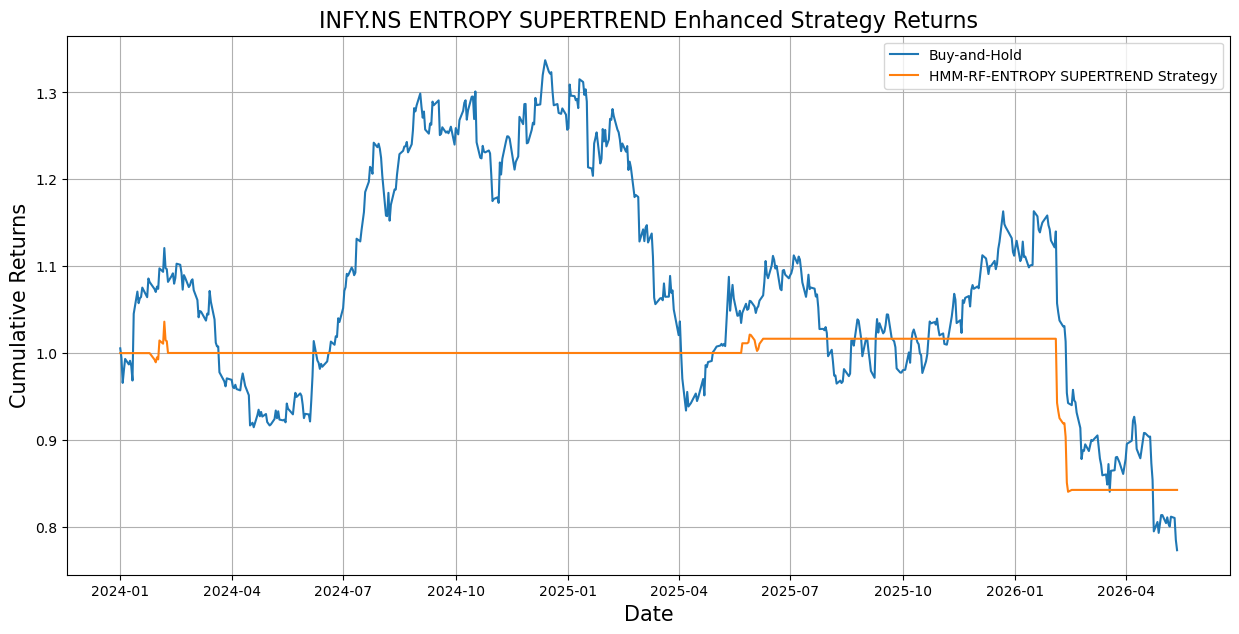

                   Buy & Hold Strategy
Annual return         -10.72%   -7.13%
Cumulative returns    -23.11%  -15.74%
Annual volatility      25.20%    7.06%
Sharpe ratio            -0.32    -1.01
Calmar ratio            -0.25    -0.38
Max drawdown          -42.17%  -18.89%
Sortino ratio           -0.45    -1.08


In [88]:
#CHANGE
# ===================================================
# PHASE 4 EXECUTION BLOCK
# HMM + RF + HURST + ENTROPY
# ===================================================

from datetime import datetime

if __name__ == '__main__':

    # -----------------------------------
    # PARAMETERS
    # -----------------------------------

    TICKER = 'INFY.NS'

    START_DATE = '2020-01-01'

    END_DATE = '2026-05-14'

    BACKTEST_SIGNAL_START_DATE = '2024-01-01'

    NUM_LEAD = 1

    # -----------------------------------
    # DOWNLOAD DATA
    # -----------------------------------

    raw_data = get_data(

        TICKER,

        START_DATE,

        END_DATE

    )

    # -----------------------------------
    # FEATURE ENGINEERING
    # -----------------------------------

    data_with_features, fixed_features = (

        engineer_features(

            raw_data.copy(),

            NUM_LEAD

        )

    )

    # -----------------------------------
    # HURST CALCULATION
    # -----------------------------------

    hurst_window = 100

    data_with_features['hurst'] = (

        data_with_features['returns']

        .rolling(hurst_window)

        .apply(

            calculate_hurst,

            raw=False

        )

    )

    # -----------------------------------
    # ENTROPY CALCULATION
    # -----------------------------------

    entropy_window = 20

    entropy_smoothing = 10

    entropy_bins = 10

    data_with_features['entropy'] = (

        data_with_features['returns']

        .rolling(entropy_window)

        .apply(

            lambda x: calculate_shannon_entropy(

                x,

                bins=entropy_bins

            ),

            raw=False

        )

    )

    # Smoothed entropy
    data_with_features['entropy_smooth'] = (

        data_with_features['entropy']

        .ewm(span=entropy_smoothing)

        .mean()

    )

    # Adaptive threshold
    adaptation_window = 100

    entropy_percentile = 80

    data_with_features['entropy_threshold'] = (

        data_with_features['entropy_smooth']

        .rolling(adaptation_window)

        .quantile(entropy_percentile / 100)

    )

    # Entropy score
    data_with_features['entropy_score'] = np.maximum(

        0,

        1 - (

            data_with_features['entropy_smooth']

            /

            data_with_features['entropy_threshold']

        )

    )

    # -----------------------------------
    # REMOVE NaNs
    # -----------------------------------

    data_with_features.dropna(inplace=True)

    print(

        f"Data prepared. "

        f"Features: {len(fixed_features)}"

    )

    print(

        f"Final shape: "

        f"{data_with_features.shape}"

    )

    # -----------------------------------
    # RUN BACKTEST
    # -----------------------------------

    results_df_phase4 = run_backtest_hurst_entropy(

        data_with_features.copy(),

        fixed_features,

        BACKTEST_SIGNAL_START_DATE,

        NUM_LEAD

    )

    # -----------------------------------
    # FILTER PLOTTING PERIOD
    # -----------------------------------

    results_to_plot_phase4 = (

        results_df_phase4[

            results_df_phase4.index >=

            pd.to_datetime(

                BACKTEST_SIGNAL_START_DATE

            )

        ].copy()

    )

    # -----------------------------------
    # PLOT RESULTS
    # -----------------------------------

    plot_results_entropy_supertrend(

        results_to_plot_phase4,

        TICKER

    )

    # -----------------------------------
    # PERFORMANCE METRICS
    # -----------------------------------

    compute_perf_stats_entropy_supertrend(

        results_to_plot_phase4

    )

In [89]:
print(
    results_df_phase4['signal']
    .value_counts()
)

signal
 0    1426
 1      27
-1       2
Name: count, dtype: int64


In [90]:
# =========================================================
# CURRENT MARKET PREDICTION PANEL
# USING:
# HMM + RF + HURST + ENTROPY
# =========================================================

def predict_current_market_status(

    data_df,

    feature_cols

):

    """
    Predicts current market condition
    using the latest available data.
    """

    # -----------------------------------
    # CLEAN DATA
    # -----------------------------------

    data_df = data_df.copy()

    data_df.dropna(inplace=True)

    # -----------------------------------
    # TRAIN DATA
    # -----------------------------------

    X_train = data_df[feature_cols]

    y_train = data_df['y_signal']

    # -----------------------------------
    # HMM MODEL
    # -----------------------------------

    hmm_model = GaussianHMM(

        n_components=2,

        covariance_type='diag',

        n_iter=1000,

        random_state=42

    )

    hmm_model.fit(

        data_df[['returns']]

    )

    hidden_states = hmm_model.predict(

        data_df[['returns']]

    )

    data_df['regime'] = hidden_states

    # -----------------------------------
    # DETERMINE BULL / BEAR REGIME
    # -----------------------------------

    regime_returns = (

        data_df

        .groupby('regime')['returns']

        .mean()

    )

    bull_regime = regime_returns.idxmax()

    # Current regime
    current_regime = data_df['regime'].iloc[-1]

    regime_label = (

        "BULL"

        if current_regime == bull_regime

        else "BEAR"

    )

    # -----------------------------------
    # RANDOM FOREST
    # -----------------------------------

    rf_model = RandomForestClassifier(

        n_estimators=200,

        max_depth=5,

        random_state=42,

        n_jobs=-1

    )

    rf_model.fit(

        X_train,

        y_train

    )

    # -----------------------------------
    # CURRENT FEATURES
    # -----------------------------------

    X_current = data_df[feature_cols].iloc[[-1]]

    prediction_probs = rf_model.predict_proba(

        X_current

    )[0]

    down_prob = prediction_probs[0]

    up_prob = prediction_probs[1]

    # -----------------------------------
    # DIRECTION
    # -----------------------------------

    if up_prob > down_prob:

        tomorrow_direction = "UP"

        confidence = up_prob

    else:

        tomorrow_direction = "DOWN"

        confidence = down_prob

    # -----------------------------------
    # HURST
    # -----------------------------------

    current_hurst = data_df['hurst'].iloc[-1]

    trend_label = (

        "TRENDING"

        if current_hurst > 0.55

        else "RANDOM"

    )

    # -----------------------------------
    # ENTROPY
    # -----------------------------------

    current_entropy = data_df['entropy_score'].iloc[-1]

    noise_label = (

        "LOW"

        if current_entropy > 0.2

        else "HIGH"

    )

    # -----------------------------------
    # FINAL RECOMMENDATION
    # -----------------------------------

    if (

        regime_label == "BULL"

        and

        tomorrow_direction == "UP"

        and

        current_hurst > 0.55

        and

        current_entropy > 0.2

    ):

        recommendation = "BUY ✓"

    elif (

        regime_label == "BEAR"

        and

        tomorrow_direction == "DOWN"

        and

        current_hurst > 0.55

        and

        current_entropy > 0.2

    ):

        recommendation = "SELL ✓"

    else:

        recommendation = "NO TRADE"

    # =====================================================
    # DISPLAY PANEL
    # =====================================================

    print("\nMarket Status Box:")
    print("┌──────────────────────────┐")

    print(

        f"│ HMM Regime: "

        f"{regime_label:<12}│"

    )

    print(

        f"│ Tomorrow: "

        f"{tomorrow_direction} "

        f"({confidence:.0%} conf)"

        f"{' ' * 4}│"

    )

    print(

        f"│ Trend: "

        f"{trend_label} "

        f"({current_hurst:.2f})"

        f"{' ' * 3}│"

    )

    print(

        f"│ Noise: "

        f"{noise_label} "

        f"({current_entropy:.2f})"

        f"{' ' * 6}│"

    )

    print(

        f"│ RECOMMENDATION: "

        f"{recommendation:<8}│"

    )

    print("└──────────────────────────┘")

    # Optional return dictionary
    return {

        'regime': regime_label,

        'direction': tomorrow_direction,

        'confidence': confidence,

        'hurst': current_hurst,

        'entropy': current_entropy,

        'recommendation': recommendation

    }

In [91]:
predict_current_market_status(

    data_with_features,

    fixed_features

)


Market Status Box:
┌──────────────────────────┐
│ HMM Regime: BULL        │
│ Tomorrow: DOWN (55% conf)    │
│ Trend: TRENDING (0.62)   │
│ Noise: HIGH (0.04)      │
│ RECOMMENDATION: NO TRADE│
└──────────────────────────┘


{'regime': 'BULL',
 'direction': 'DOWN',
 'confidence': np.float64(0.5456598997702039),
 'hurst': np.float64(0.6169023405790969),
 'entropy': np.float64(0.04390643219464185),
 'recommendation': 'NO TRADE'}